# 문체위 국정감사 6년 — Evidence Pipeline

이 노트북은 `P3_0722` 파이프라인의 독자·편집자용 최종 점검본이다. 42개 회의록 PDF와 확정 marker 297건을 연결한 자동 후보를 보여 주되, Gold qrels·수동 Q/A 검수·외부 완료검증 전에는 공개 사실로 단정하지 않는다.

핵심 질문은 **“국정감사에서 요구된 문제는 어떤 답변을 거쳐 어떤 처리결과로 남았는가?”**이다.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Image, Markdown

ROOT = Path.cwd()
if not (ROOT / 'outputs' / 'pipeline_manifest.json').exists():
    raise FileNotFoundError('P3_0722 폴더에서 실행해야 합니다.')
manifest = json.loads((ROOT / 'outputs' / 'pipeline_manifest.json').read_text(encoding='utf-8'))
print('run:', manifest['pipeline_run_id'])
print('status:', manifest['status'])

run: RUN_20260722T052913Z_D9E75E
status: PIPELINE_CONDITIONAL_REVIEW_REQUIRED


## 1. 데이터 범위와 provenance

,dataset,row_count,analysis_unit
0,meeting_registry,42,회의록 PDF
1,pages,4495,물리 페이지
2,blocks,293717,물리 block
3,speaker_turns,65590,canonical turn
4,retrieval_segments,196686,검색 window
5,target_issues,297,확정 marker
6,target_segment_candidates,14850,시간 적격 sparse 후보
7,answer_units,25931,역할 기반 답변 후보
8,target_answer_links,1476,target-answer 후보 연결


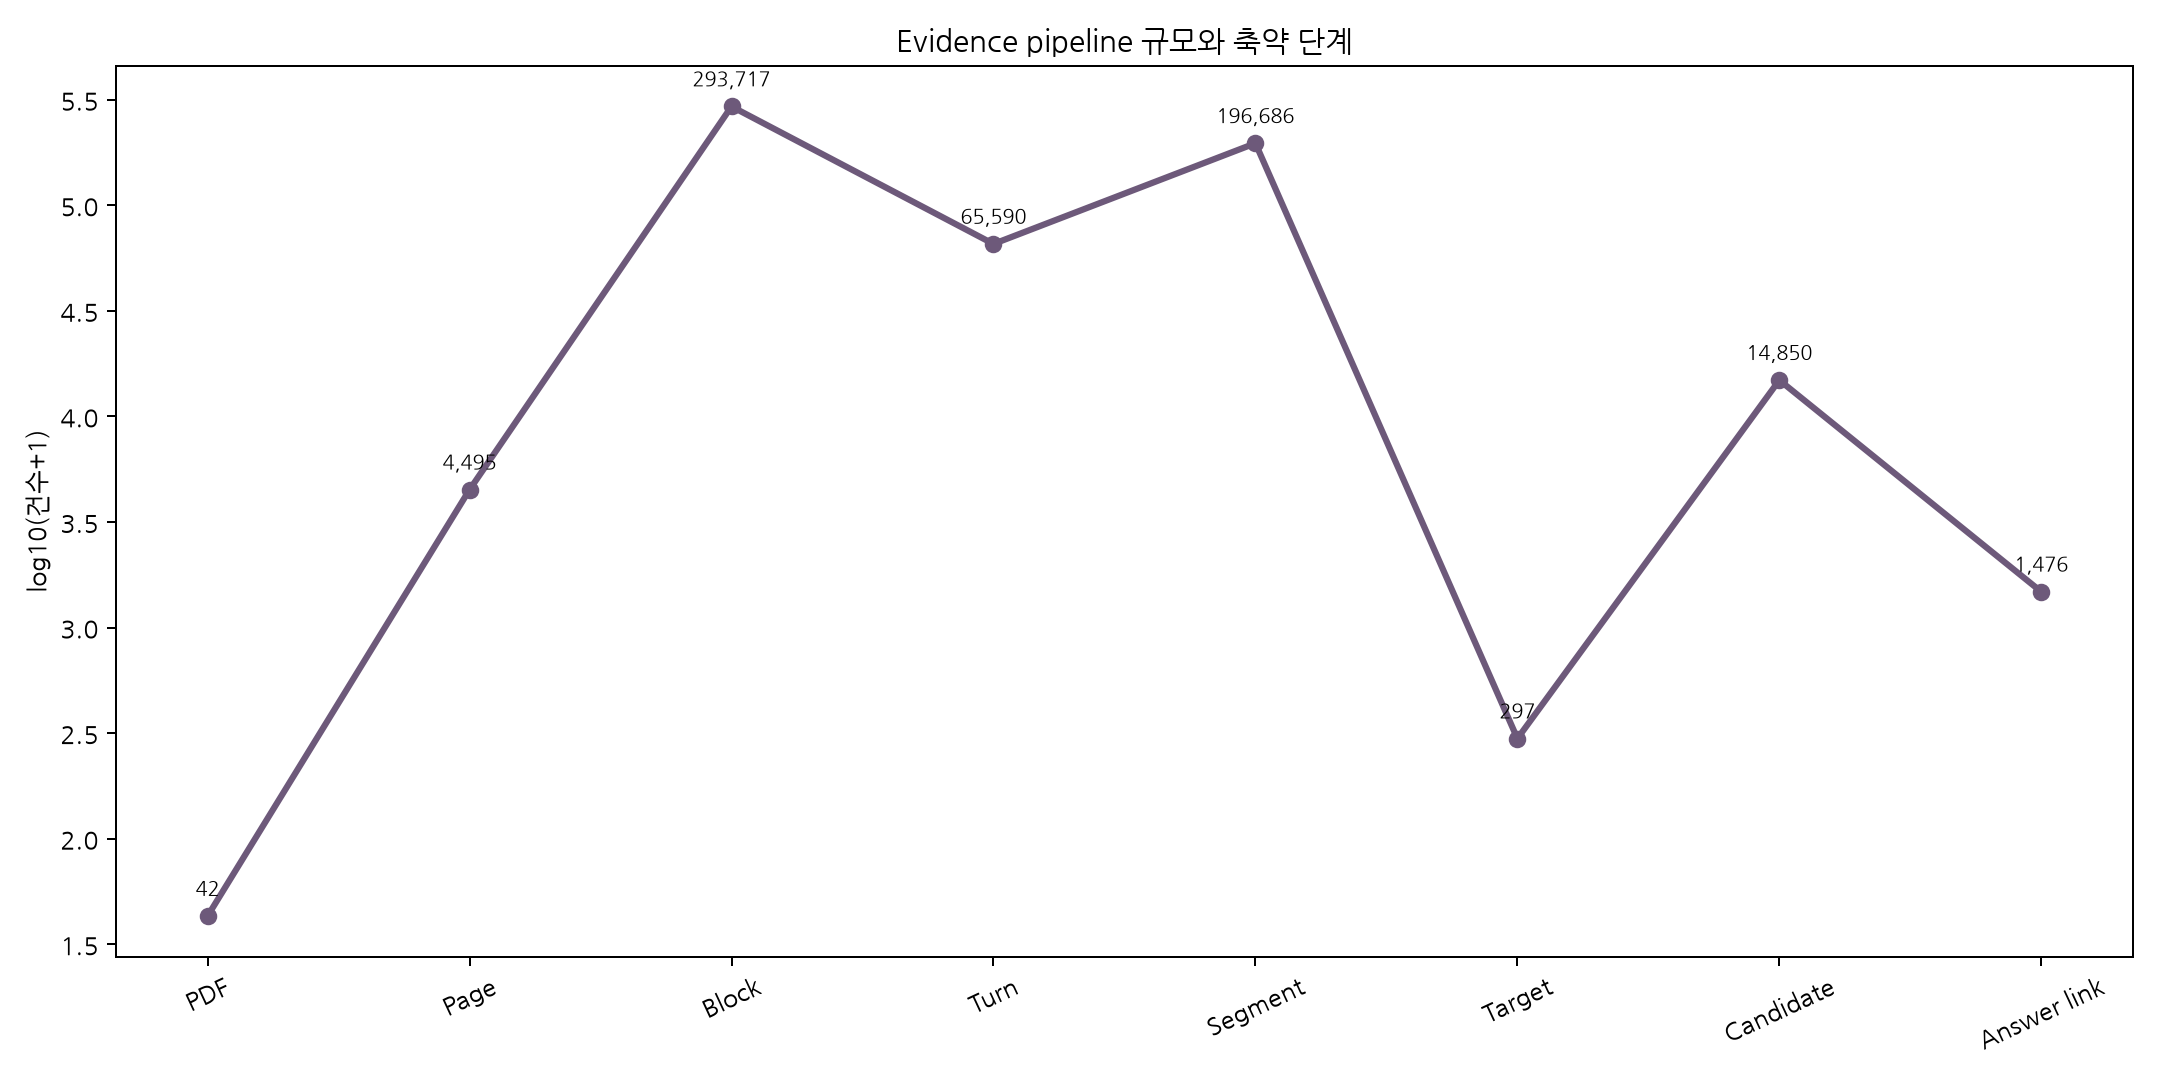

In [2]:
overview = pd.read_csv(ROOT / 'evidence' / 'dataset_overview.csv', encoding='utf-8-sig')
display(overview)
display(Image(filename=str(ROOT / 'figures' / '04_pipeline_scale.png')))

## 2. Gate — 자동 파이프라인 완료와 공개 준비는 다르다

In [3]:
gate_df = pd.DataFrame(manifest['gates'].items(), columns=['gate', 'status'])
display(gate_df)
display(Markdown('**현재 판정:** 자동 후보·번들 생성은 완료했지만 수동 qrels/Q&A/행태/완료 검증이 남아 있습니다.'))

,gate,status
0,P0_CANONICAL_ETL,PASS
1,P1_TARGET_SCHEMA,PASS
2,P2_TEMPORAL_ELIGIBILITY,PASS
3,P3_SPARSE_RETRIEVAL,PASS_BASELINE
4,P4_QRELS,REVIEW_REQUIRED
5,P5_QA_PAIR,CONDITIONAL_RULE_CANDIDATES
6,P6_ANSWER_TAXONOMY,CONDITIONAL_WEAK_RULE
7,P7_DENSE_HYBRID,PASS_CANDIDATE_POOL_RERANK
8,P8_PROJECTION_NODES,PASS_COMMON_MULTILINGUAL_UMAP
9,P9_EDITORIAL,DRAFT_REVIEW_REQUIRED


**현재 판정:** 자동 후보·번들 생성은 완료했지만 수동 qrels/Q&A/행태/완료 검증이 남아 있습니다.

## 3. 확정 marker 2020·2022·2024

,source_year,status_canvas,count
0,2020,active,54
1,2020,complete,56
2,2022,active,39
3,2022,complete,77
4,2024,active,34
5,2024,complete,37


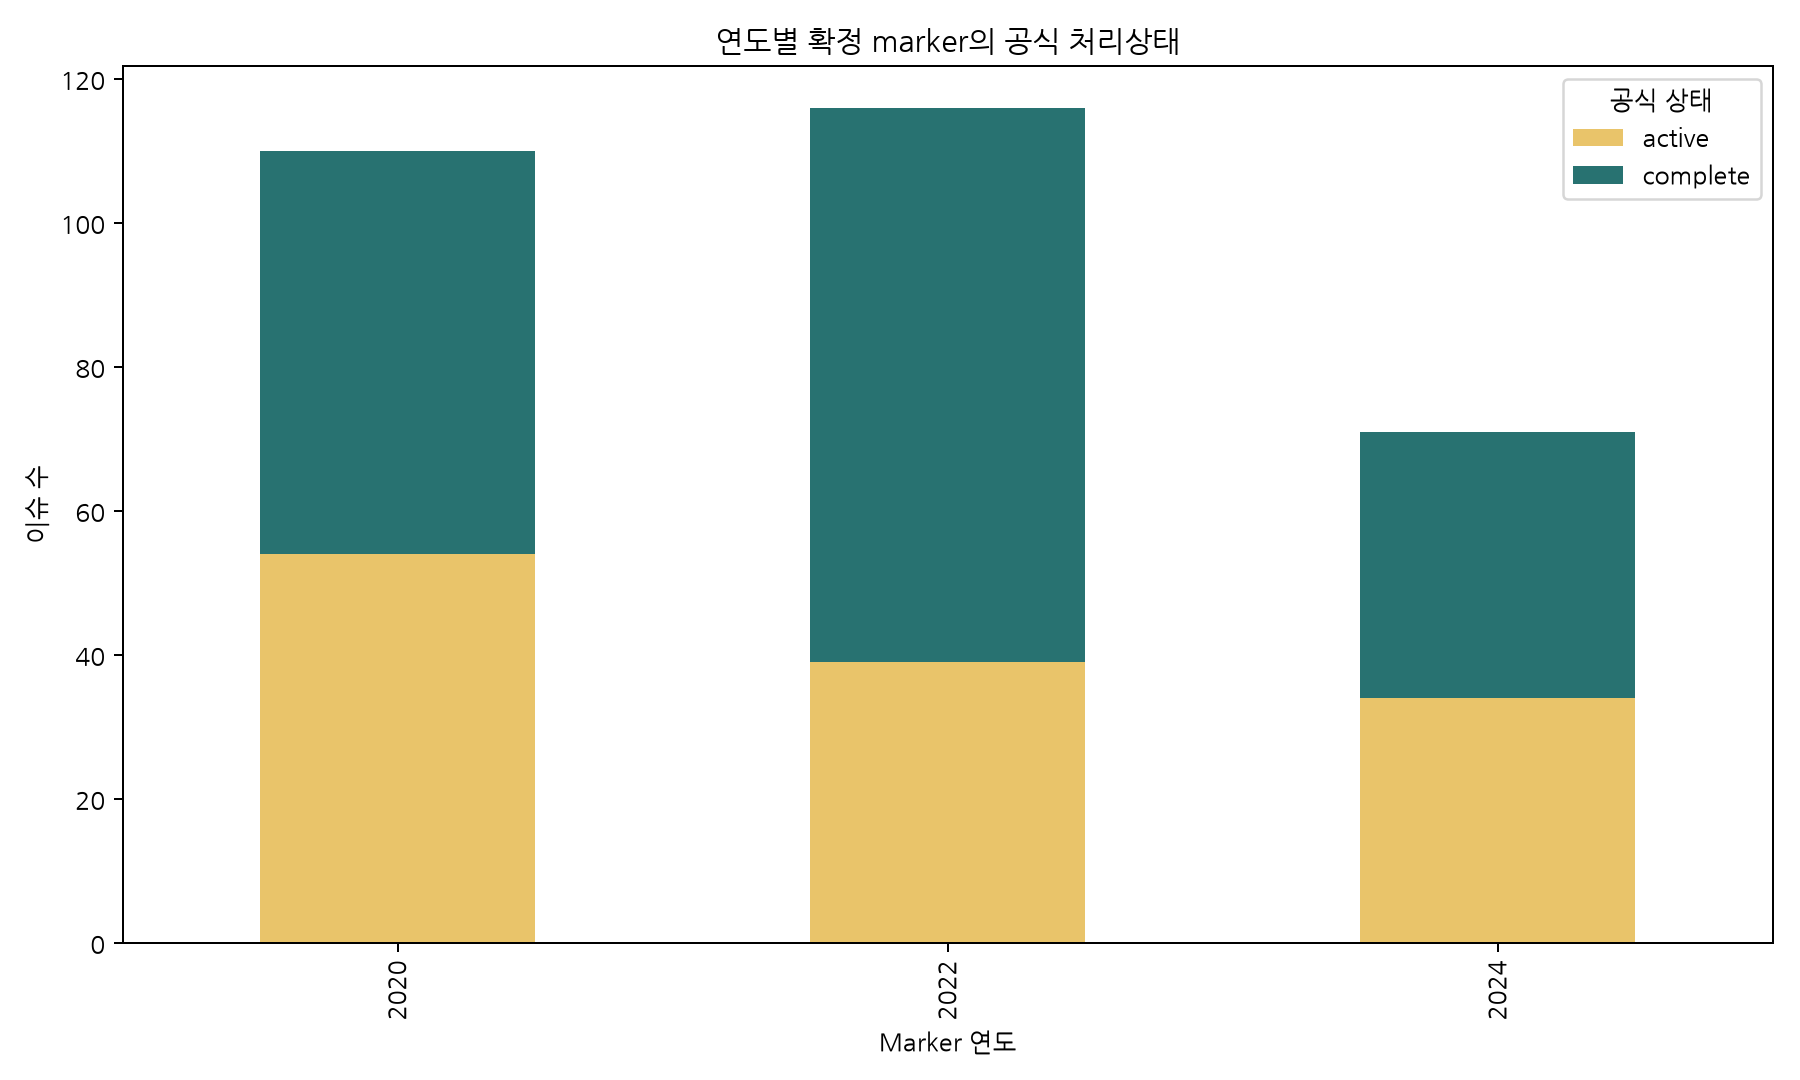

In [4]:
targets = pd.read_parquet(ROOT / 'data' / 'target' / 'target_issues.parquet')
display(targets.groupby(['source_year','status_canvas']).size().rename('count').reset_index())
display(Image(filename=str(ROOT / 'figures' / '01_target_status_by_year.png')))

## 4. 답변 단위와 행태 후보

answer_units: 25931
traceability: 1.0


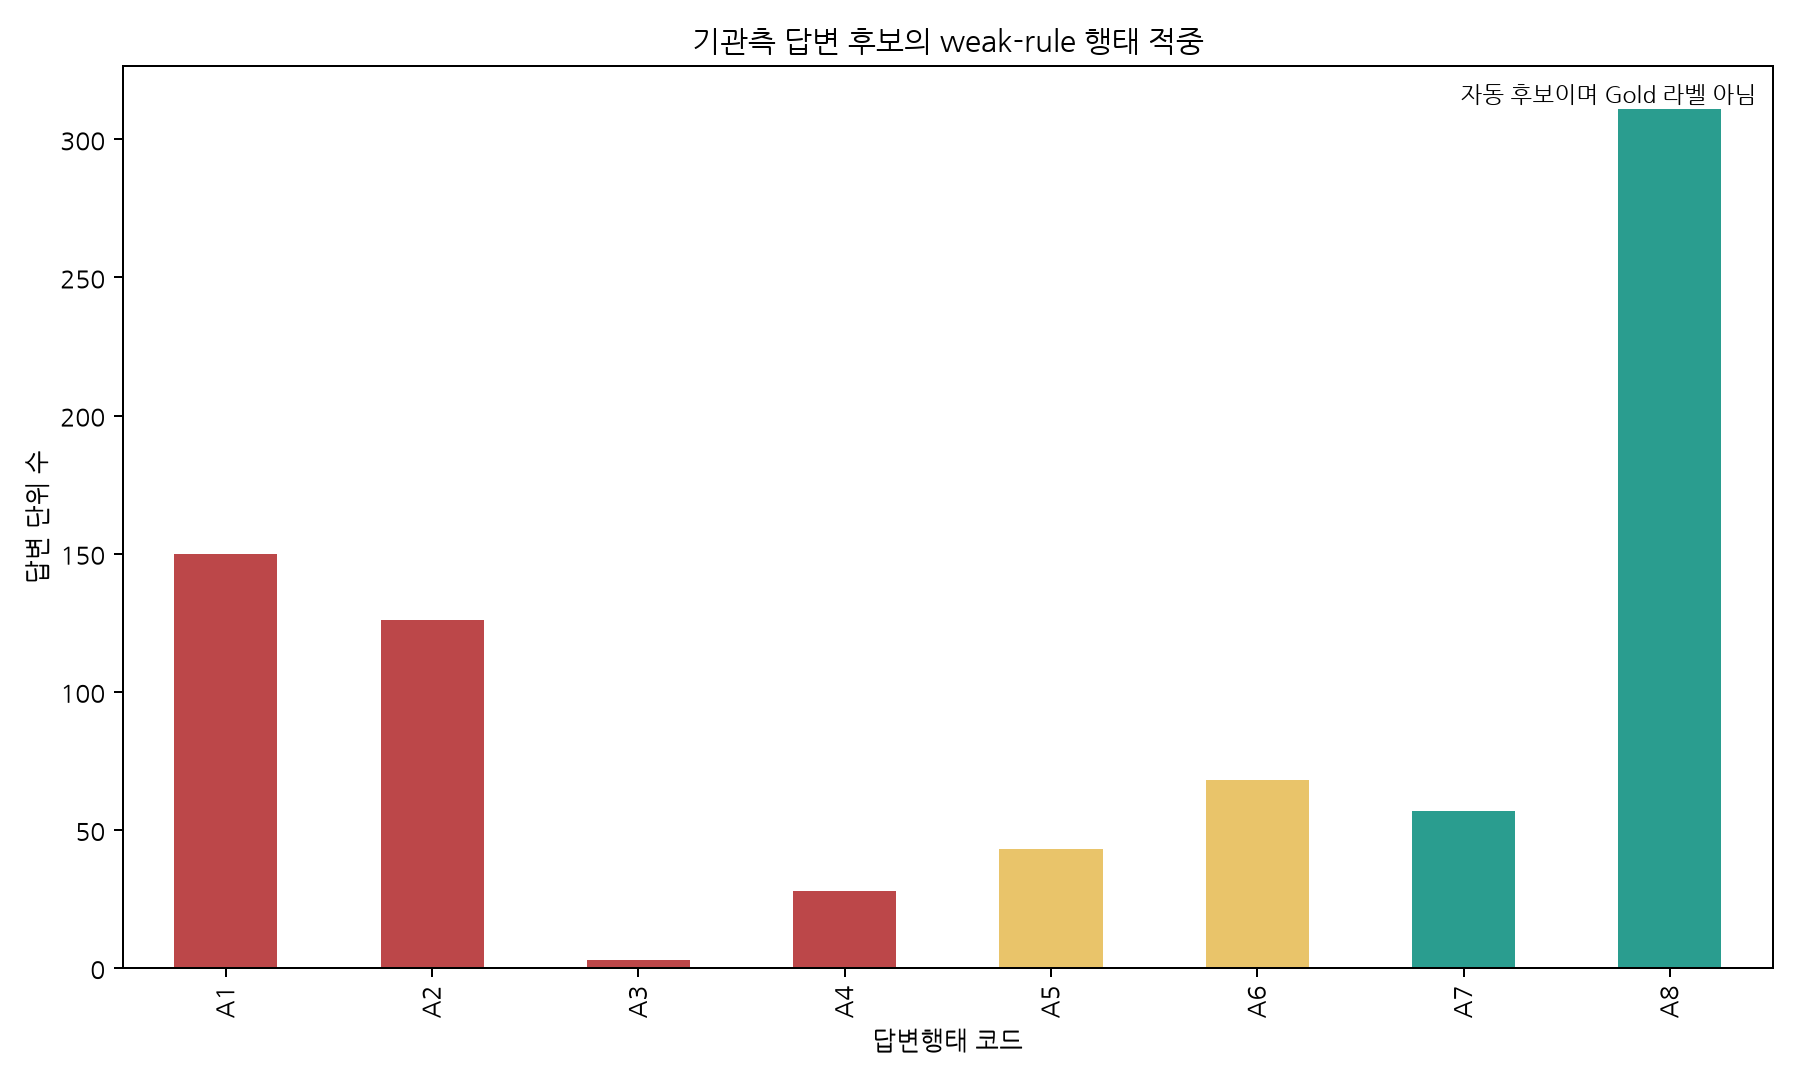

A1~A8은 첫 매칭에서 중단하지 않는 multi-hit 후보이며, Gold 라벨이 아닙니다.

In [5]:
answers = pd.read_parquet(ROOT / 'data' / 'qa' / 'answer_units.parquet')
labels = pd.read_parquet(ROOT / 'data' / 'qa' / 'answer_behavior_labels.parquet')
print('answer_units:', len(answers))
print('traceability:', (answers['traceability_status'] == 'PASS').mean())
display(Image(filename=str(ROOT / 'figures' / '02_behavior_weak_rule_counts.png')))
display(Markdown('A1~A8은 첫 매칭에서 중단하지 않는 multi-hit 후보이며, Gold 라벨이 아닙니다.'))

## 5. 한 evidence chain 역추적

In [6]:
links = pd.read_parquet(ROOT / 'data' / 'qa' / 'target_answer_links.parquet')
qa = pd.read_parquet(ROOT / 'data' / 'qa' / 'qa_pairs.parquet')
evidence = pd.read_parquet(ROOT / 'data' / 'editorial' / 'evidence_records.parquet')
sample = (evidence.head(1)
          .merge(targets[['target_issue_id','issue_text','status_canvas']], on='target_issue_id')
          .merge(qa[['qa_pair_id','question_text','answer_text']], on='qa_pair_id'))
display(sample.T)
display(Markdown('`target → link → Q/A → answer → turn → block → page → PDF`를 ID로 복원할 수 있습니다.'))

,0
evidence_id,EVD_TGT_2020_0004_CA42E938
target_issue_id,TGT_2020_0004
qa_pair_id,QA_050308_000018
target_answer_link_id,LINK_TGT_2020_0004_CA42E938
answer_label_id,ALBL_2562250D_V100
verification_id,VER_TGT_2020_0004_R1
primary_segment_no,050308_SEG_TURN_00074
meeting_id,050308
page_start_no,11
page_end_no,11


`target → link → Q/A → answer → turn → block → page → PDF`를 ID로 복원할 수 있습니다.

## 6. 가설·진단 결과와 안전 문장

,hypothesis,article_question,test,effect_size_name,effect_size,safe_sentence,avoid
0,H1,공식 처리상태 구성은 marker 연도별로 다른가?,chi_square,Cramer's V,0.148194,확정 marker의 공식 상태 구성은 연도별 차이를 보였고 효과크기는 0.15였다.,연도 자체가 이행 상태를 만들었다.
1,H2,공식 상태별 top sparse 검색 점수 분포가 다른가?,Mann-Whitney U,rank-biserial approximation,0.000371,검색 점수 차이는 retrieval 후보 품질 진단이며 이행 상태의 원인으로 해석하...,완료 여부가 회의록 답변 유사도를 결정했다.
2,H3,답변 길이와 규칙 기반 Q/A confidence가 단조 관계를 보이는가?,Spearman,Spearman rho,-0.021650,길이와 Q/A confidence의 관계는 resolver 진단값이며 답변 품질의 ...,긴 답변이 더 정확하거나 성실하다.


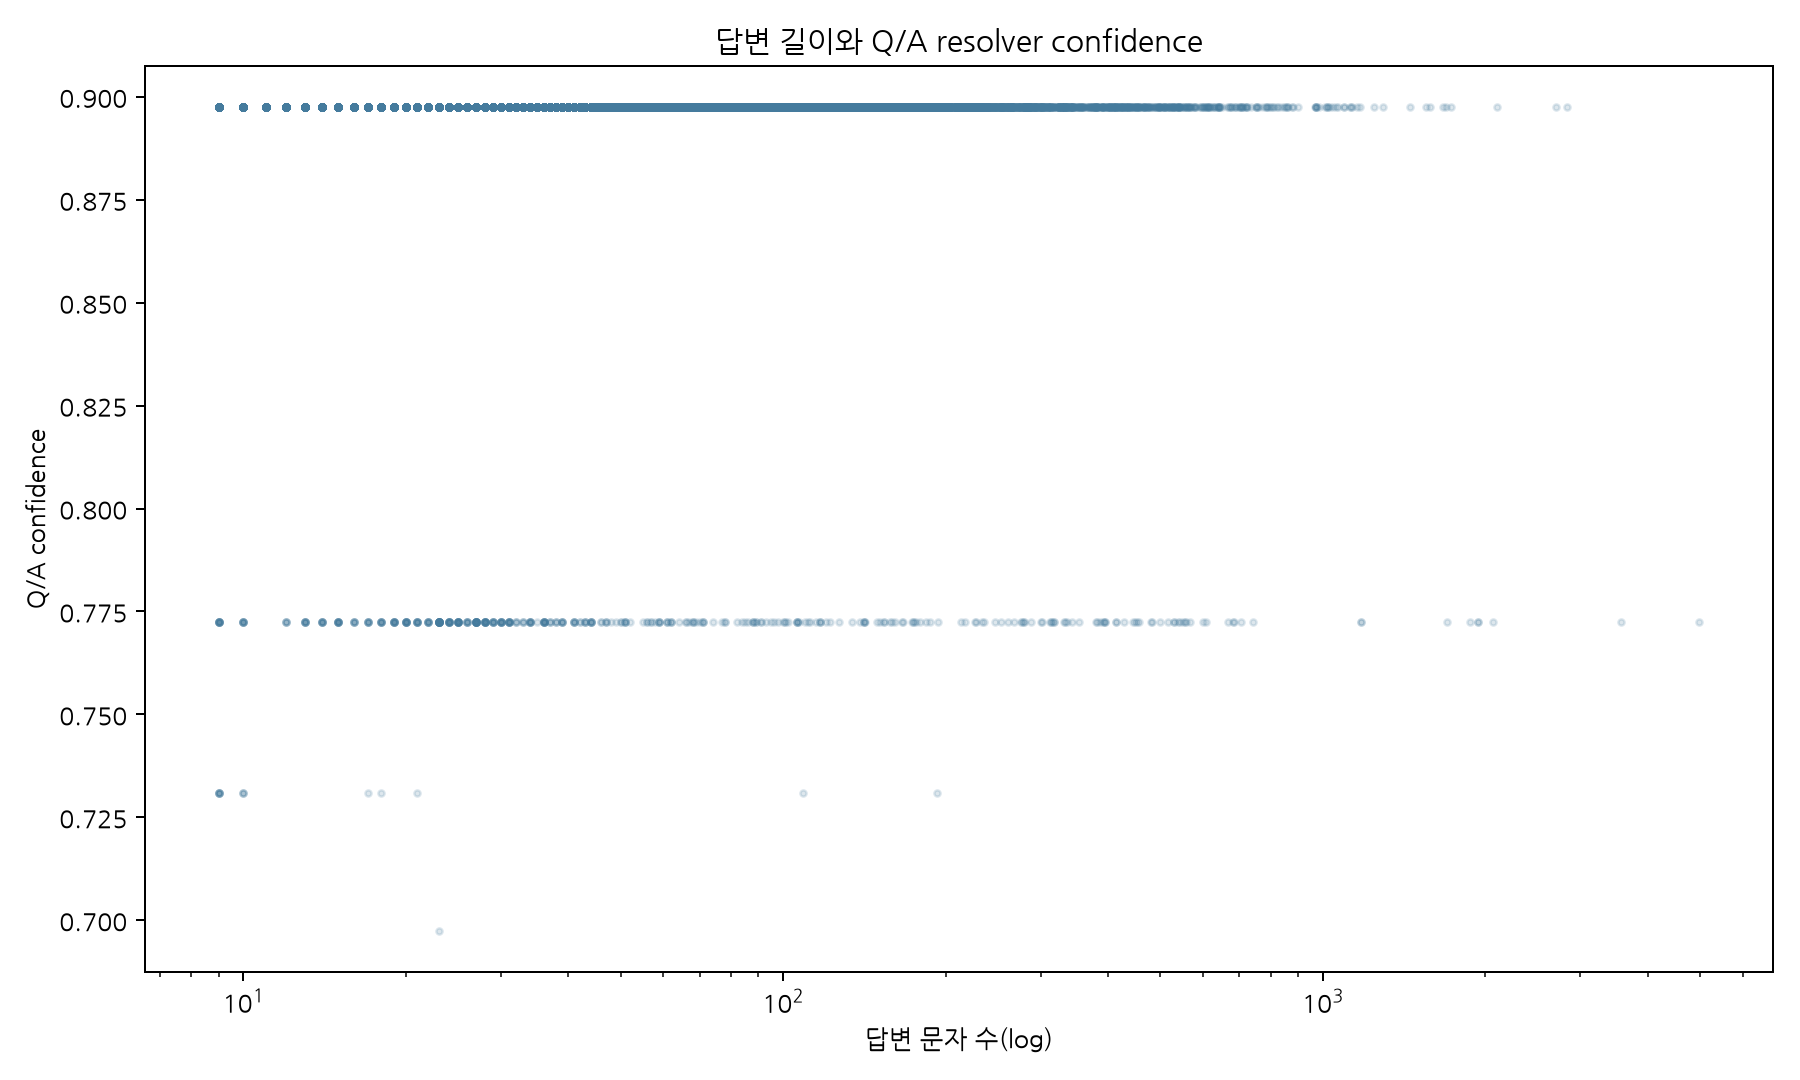

In [7]:
hypothesis = pd.read_csv(ROOT / 'data' / 'analysis_csv' / 'hypothesis_result_summary.csv', encoding='utf-8-sig')
display(hypothesis[['hypothesis','article_question','test','effect_size_name','effect_size','safe_sentence','avoid']])
display(Image(filename=str(ROOT / 'figures' / '03_answer_length_qa_confidence.png')))

## 7. 편집 한계와 다음 검수

- `data/qrels/qrels_review_queue.csv`: 400건을 relevance 0/1/2로 검수해야 한다.
- `outputs/answer_review_sample.csv`: Q/A precision과 A1~A8 weak-rule precision을 측정해야 한다.
- `completion_verifications`: 현재 전부 `not_reviewed`다.
- 2025 회의록은 2020·2022·2024 target retrieval에서 제외했다.
- 다국어 MiniLM + 공통 PCA50/UMAP은 실행했지만, Gold qrels 전에는 투영의 편집적 대표성을 승인하지 않는다.

따라서 현재 데이터로 쓸 수 있는 문장은 **구조·규모·자동 후보에 대한 기술적·서술적 문장**이며, “회피율”, “실제 완료율”, “기관별 책임”을 확정적으로 말하면 안 된다.